#  Hamile Kadınların Risk Analizi - Makine Öğrenmesi Projesi

* **Temel Amaç:** IoT tabanlı verilerle hamilelik risk düzeyini tahmin etmek.
* **Veri Kaynağı:** UCI Machine Learning - Maternal Health Risk Dataset https://archive.ics.uci.edu/dataset/863/maternal+health+risk

* **Kullanılan Mimari:** Veri Ön İşleme -> SMOTE Dengeleme -> Özellik Mühendisliği -> Sınıflandırma.


---

# 1. Veri Seti Tanıtımı
- **Age:** Anne adayının yaşı.
- **SystolicBP:** Büyük tansiyon (mmHg).
- **DiastolicBP:** Küçük tansiyon (mmHg).
- **BS:** Kan şekeri seviyesi (mmol/L).
- **BodyTemp:** Vücut ısısı (Fahrenheit).
- **HeartRate:** Kalp atış hızı (bpm).
- **RiskLevel (Target):** Hedef değişken (low risk, mid risk, high risk).



Bangladeş kaynaklı 1014 örnek ve 6 biyometrik özellik (Yaş, Tansiyon, Şeker vb.) içeren veri seti kullanılmıştır. Projenin temel amacı, bu verilerle hastaların risk durumlarını doğru sınıflandırmaktır .

###1.2 Problemin Tanımı
Hamile kadınların tansiyon، şeker ve nabız gibi hayati verilerinin anlık takip edilememesi ve riskli durumların geç fark edilerek hayati tehlike oluşturması.


###1.3 Sunulan Çözüm
IoT verilerini makine öğrenmesi ile analiz ederek anne adayının risk seviyesini anında tahmin eden ve erken uyarı veren akıllı bir sistem.


###1.4. Hedef Değişken (Target Variable)

Projenin çıktı sütunu olan RiskLevel, hamilelik riskini "Düşük, Orta, Yüksek" olarak sınıflandıran kategorik bir değişkendir. Algoritmaların veriyi işleyebilmesi için bu sınıflar mantıksal sıralamaya uygun olarak sayısal değerlere (low risk: 0, mid risk: 1, high risk: 2) dönüştürülerek (Ordinal Encoding) modele hazır hale getirilmiştir.



###1.5. Metodolojik Yaklaşım

Bu çalışmada; KNN, Naive Bayes, Decision Tree ve Random Forest algoritmaları kullanılarak karşılaştırmalı bir analiz yapılmıştır. Normalizasyon ve özellik seçimi yöntemleriyle, anne sağlığı verilerinde en yüksek güvenilirlik ve doğruluk (Accuracy) oranını sunan modelin belirlenmesi hedeflenmiştir.

# 2. Veri setinin okunması ve genel yapısı

In [1]:
# Veri işlemleri için pandas kütüphanesini içe aktarma
import pandas as pd

# 1. Veri setinin okunması
# Dosya adının dizindeki dosyayla tam olarak eşleştiğinden emin olun
df = pd.read_csv('MaternalHealthRiskDataSet.csv')

# Verinin genel yapısını görmek için ilk 5 satırın gösterilmesi
print("\n--- Veri Setinin İlk 5 Satırı ---\n")
display(df.head())

# 2. Satır ve sütun sayılarının gösterilmesi
print(f"\n--- Satır ve Sütun Sayıları: {df.shape} ---")
print("\nVeri setimiz 1014 satır ve 7 sütundan oluşmaktadır. Bu, model eğitimi için yeterli bir veri hacmine sahip olduğumuzu göstermektedir.\n")

# 3. Sütun adlarının ve veri türlerinin gösterilmesi
print("\n--- Sütun Adları, Veri Türleri ve Genel Bilgiler ---\n")
df.info()


--- Veri Setinin İlk 5 Satırı ---



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk



--- Satır ve Sütun Sayıları: (1014, 7) ---

Veri setimiz 1014 satır ve 7 sütundan oluşmaktadır. Bu, model eğitimi için yeterli bir veri hacmine sahip olduğumuzu göstermektedir.


--- Sütun Adları, Veri Türleri ve Genel Bilgiler ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


#3. İstatistiksel Analiz




--- Temel İstatistiksel Analiz Tablosu ---



,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0



İstatistiksel Analiz ve Veri Dağılımı: 
df.describe() çıktısı incelendiğinde, anne sağlığı parametrelerinin dağılımı hakkında şu önemli bulgular elde edilmiştir:
Yaş Dağılımı (Age): Katılımcıların yaş ortalaması yaklaşık 29.8'dir. En genç anne adayının 13, en yaşlısının ise 70 yaşında olması, veri setinin çok geniş bir yaş yelpazesini kapsadığını göstermektedir.
Kan Şekeri (BS): Kan şekeri değerleri ortalama 8.72 seviyesindedir. Ancak maksimum değerin 19'a kadar çıkması, veri setinde ciddi diyabetik risk taşıyan vakaların bulunduğuna işaret eder.
Kan Basıncı (Systolic & Diastolic BP): * Büyük tansiyon (SystolicBP) ortalaması 113 mmHg, maksimum 160 mmHg'dir.
Küçük tansiyon (DiastolicBP) ortalaması 76 mmHg, maksimum 100 mmHg'dir.
Bu değerler, veri setinde yüksek tansiyon (hipertansiyon) riski taşıyan hastaların oranının analiz için yeterli olduğunu kanıtlar. 
Vücut Isısı (BodyTemp): Ortalama vücut ısısı 98.66 °F ile normal sınırlar içerisindedir. Ancak bazı vakalarda 103 °F (yüksek ateş

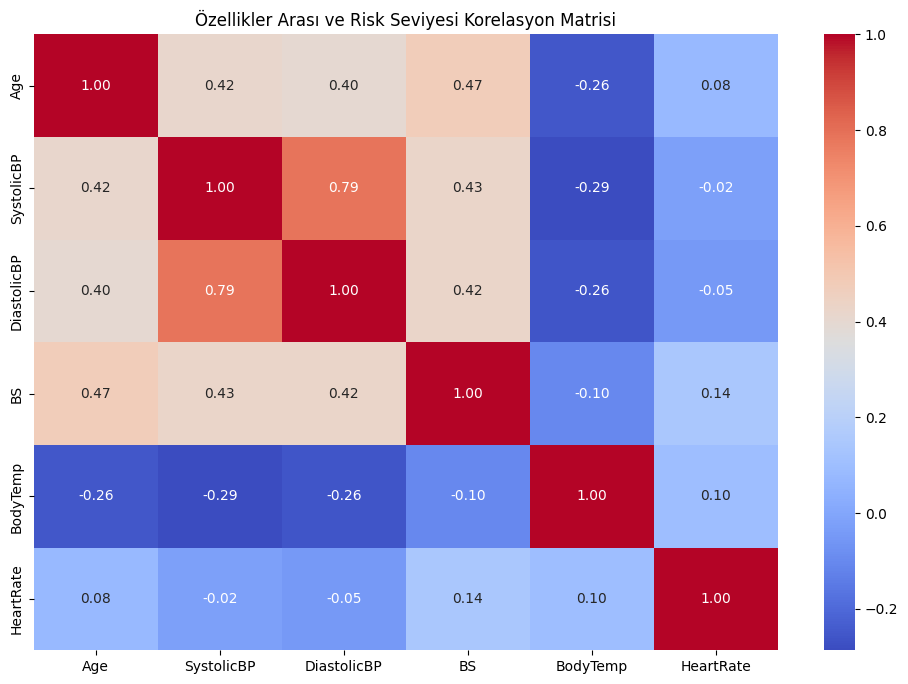



--- Hedef Değişken (RiskLevel) Dağılımı ---



,count
RiskLevel,
low risk,406
mid risk,336
high risk,272


In [2]:
# 3. İstatistiksel Analiz
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Temel İstatistiksel Analiz Tablosu ---\n")
istatistiksel_ozet = df.describe().T
display(istatistiksel_ozet)

print("\nİstatistiksel Analiz ve Veri Dağılımı: \ndf.describe() çıktısı incelendiğinde, anne sağlığı parametrelerinin dağılımı hakkında şu önemli bulgular elde edilmiştir:\nYaş Dağılımı (Age): Katılımcıların yaş ortalaması yaklaşık 29.8'dir. En genç anne adayının 13, en yaşlısının ise 70 yaşında olması, veri setinin çok geniş bir yaş yelpazesini kapsadığını göstermektedir.\nKan Şekeri (BS): Kan şekeri değerleri ortalama 8.72 seviyesindedir. Ancak maksimum değerin 19'a kadar çıkması, veri setinde ciddi diyabetik risk taşıyan vakaların bulunduğuna işaret eder.\nKan Basıncı (Systolic & Diastolic BP): * Büyük tansiyon (SystolicBP) ortalaması 113 mmHg, maksimum 160 mmHg'dir.\nKüçük tansiyon (DiastolicBP) ortalaması 76 mmHg, maksimum 100 mmHg'dir.\nBu değerler, veri setinde yüksek tansiyon (hipertansiyon) riski taşıyan hastaların oranının analiz için yeterli olduğunu kanıtlar. \nVücut Isısı (BodyTemp): Ortalama vücut ısısı 98.66 °F ile normal sınırlar içerisindedir. Ancak bazı vakalarda 103 °F (yüksek ateş) gözlemlenmiştir, bu da enfeksiyon kaynaklı risklerin model tarafından öğrenilmesini sağlar.\nKalp Atış Hızı (HeartRate): Ortalama nabız 74.3 olup, 60 ile 90 arasında sağlıklı bir dağılım sergilemektedir.\n\nSonuç: Değişkenlerin standart sapma (std) değerleri incelendiğinde, verilerin çok dar bir alana sıkışmadığı ve modellerin risk seviyelerini ayırt edebilmesi için yeterli varyasyona sahip olduğu saptanmıştır.\n\n")

plt.figure(figsize=(12, 8))

# Numeric özelliklerin korelasyonunu alırken artık RiskLevel_Encoded da dahil olacak
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# Başlık güncellendi
plt.title('Özellikler Arası ve Risk Seviyesi Korelasyon Matrisi')
plt.show()

print("\n\n--- Hedef Değişken (RiskLevel) Dağılımı ---\n")
display(df['RiskLevel'].value_counts())
print("\n")

/tmp/ipykernel_12398/189616694.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y='BS', palette='magma', order=risk_sirasi)
/tmp/ipykernel_12398/189616694.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='RiskLevel', y='SystolicBP', palette='rocket', order=risk_sirasi, inner="quartile")


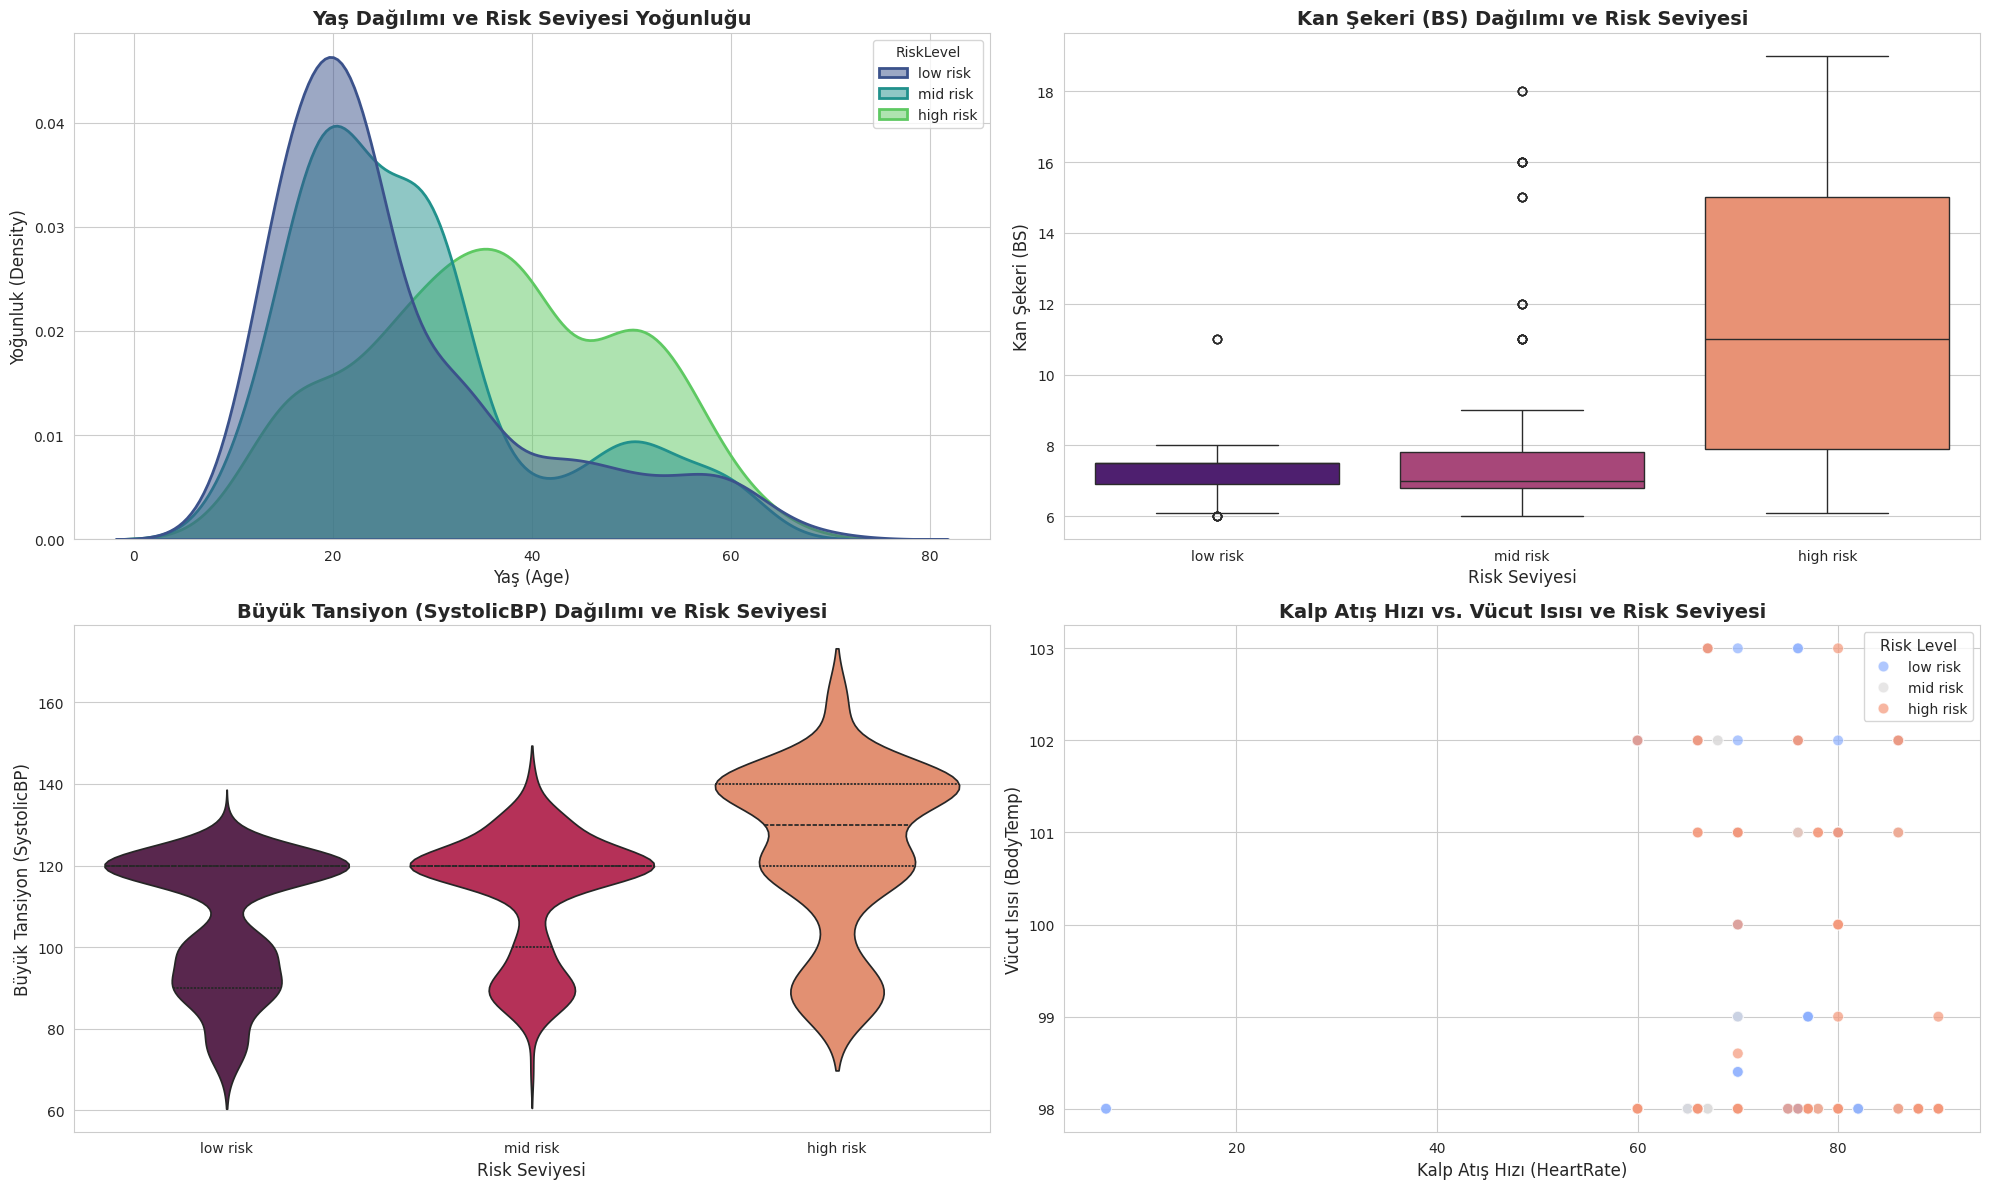

In [3]:
# 1.2. Gelişmiş Veri Görselleştirme ve Özellik Analizi (Teknik)
# Amacı: Her bir tıbbi özelliğin RiskLevel üzerindeki etkisini ve dağılımını analiz etmek.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Grafiklerin genel stilini ve boyutunu ayarla
sns.set_style("whitegrid")
plt.figure(figsize=(20, 12))

# Mantıksal sıralamayı tüm grafiklerde sabit tutmak için değişken oluşturuyoruz
risk_sirasi = ['low risk', 'mid risk', 'high risk']

# 1. Grafik: Yaş Dağılımı ve Risk Seviyesi (KDE Plot - Yoğunluk)
plt.subplot(2, 2, 1)
sns.kdeplot(data=df, x='Age', hue='RiskLevel', hue_order=risk_sirasi, fill=True, common_norm=False, palette='viridis', alpha=0.5, linewidth=2)
plt.title('Yaş Dağılımı ve Risk Seviyesi Yoğunluğu', fontsize=14, fontweight='bold')
plt.xlabel('Yaş (Age)', fontsize=12)
plt.ylabel('Yoğunluk (Density)', fontsize=12)

# 2. Grafik: Kan Şekeri Dağılımı ve Risk Seviyesi (Box Plot - Kutu Grafiği)
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='RiskLevel', y='BS', palette='magma', order=risk_sirasi)
plt.title('Kan Şekeri (BS) Dağılımı ve Risk Seviyesi', fontsize=14, fontweight='bold')
plt.xlabel('Risk Seviyesi', fontsize=12)
plt.ylabel('Kan Şekeri (BS)', fontsize=12)

# 3. Grafik: Büyük Tansiyon Dağılımı ve Risk Seviyesi (Violin Plot - Keman Grafiği)
plt.subplot(2, 2, 3)
sns.violinplot(data=df, x='RiskLevel', y='SystolicBP', palette='rocket', order=risk_sirasi, inner="quartile")
plt.title('Büyük Tansiyon (SystolicBP) Dağılımı ve Risk Seviyesi', fontsize=14, fontweight='bold')
plt.xlabel('Risk Seviyesi', fontsize=12)
plt.ylabel('Büyük Tansiyon (SystolicBP)', fontsize=12)

# 4. Grafik: Kalp Atış Hızı ve Vücut Isısı (Scatter Plot - Serpilme Grafiği)
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='HeartRate', y='BodyTemp', hue='RiskLevel', hue_order=risk_sirasi, palette='coolwarm', alpha=0.7, s=60)
plt.title('Kalp Atış Hızı vs. Vücut Isısı ve Risk Seviyesi', fontsize=14, fontweight='bold')
plt.xlabel('Kalp Atış Hızı (HeartRate)', fontsize=12)
plt.ylabel('Vücut Isısı (BodyTemp)', fontsize=12)
plt.legend(title='Risk Level', title_fontsize='11', loc='upper right')

# Grafikleri düzenli ve okunabilir şekilde yerleştir
plt.tight_layout()
plt.show()

# 4. Veri Hazırlama ve Ön İşleme


--- 1. Eksik Verilerin İncelenmesi ---

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Sonuç: Veri setinde eksik (NaN/Null) veri bulunmaması, veri bütünlüğünün tam olduğunu gösterir.

--- 2. Encoding (Kategorik Veriyi Sayısallaştırma) ---



,RiskLevel,RiskLevel_Encoded
752,mid risk,1
519,high risk,2
210,high risk,2
611,low risk,0
914,low risk,0


Uygulama: Risk seviyeleri mantıksal sırayla kodlandı: {'low risk': 0, 'mid risk': 1, 'high risk': 2}

--- 3. Train-Test Split (Veri Bölme) ---

Veri Bölündü: Eğitim Seti = 811 örnek | Test Seti = 203 örnek.

--- 4. SMOTE (Sınıf Dengesizliğini Giderme) ---



/tmp/ipykernel_12398/2754636982.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x=y_train, palette='muted')
/tmp/ipykernel_12398/2754636982.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(etiketler)
/tmp/ipykernel_12398/2754636982.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x=y_train_resampled, palette='muted')
/tmp/ipykernel_12398/2754636982.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(etiketler)


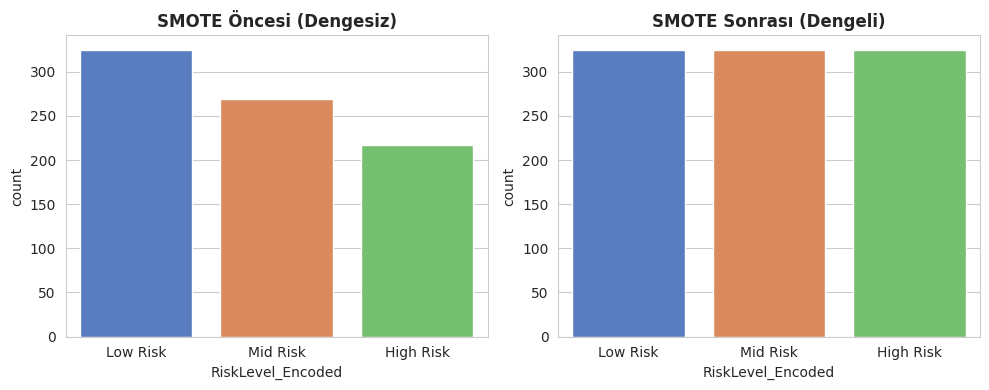


--- 5. Normalization/Standardization (Veri Ölçeklendirme) ---



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,0.021064,0.282975,-1.239405,-0.831677,-0.496577,0.199771
1,-0.572066,0.282975,0.899896,-0.332688,-0.496577,-1.731098
2,-1.313477,-1.311212,-0.882855,-0.420745,1.695952,0.682488


Sonuç: Veriler aynı ölçeğe getirildi. Model Eğitimi için hazır!


In [4]:
# 4. Veri Hazırlama ve Ön İşleme
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Veri Setinin İncelenmesi
print("\n--- 1. Eksik Verilerin İncelenmesi ---\n")
eksik_veriler = df.isnull().sum()
print(eksik_veriler)
print("\nSonuç: Veri setinde eksik (NaN/Null) veri bulunmaması, veri bütünlüğünün tam olduğunu gösterir.")

# 2. Encoding (Kategorik Veriyi Sayısallaştırma) - Ordinal Approach
print("\n--- 2. Encoding (Kategorik Veriyi Sayısallaştırma) ---\n")
# Risk seviyelerini mantıksal ve ordinal bir sırayla kodluyoruz
risk_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['RiskLevel_Encoded'] = df['RiskLevel'].map(risk_mapping)

# Çıktının her çalıştırıldığında aynı kalması için random_state eklendi
display(df[['RiskLevel', 'RiskLevel_Encoded']].sample(5, random_state=42))
print(f"Uygulama: Risk seviyeleri mantıksal sırayla kodlandı: {risk_mapping}")

# 3. Train-Test Split
print("\n--- 3. Train-Test Split (Veri Bölme) ---\n")
X = df.drop(['RiskLevel', 'RiskLevel_Encoded'], axis=1)
y = df['RiskLevel_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Veri Bölündü: Eğitim Seti = {X_train.shape[0]} örnek | Test Seti = {X_test.shape[0]} örnek.")

# 4. SMOTE
print("\n--- 4. SMOTE (Sınıf Dengesizliğini Giderme) ---\n")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(10, 4))

# Görselleştirmenin profesyonel olması için x eksenindeki 0, 1, 2 değerlerini isimlendiriyoruz
etiketler = ['Low Risk', 'Mid Risk', 'High Risk']

plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y_train, palette='muted')
ax1.set_xticklabels(etiketler)
plt.title('SMOTE Öncesi (Dengesiz)', fontweight='bold')

plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_train_resampled, palette='muted')
ax2.set_xticklabels(etiketler)
plt.title('SMOTE Sonrası (Dengeli)', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Normalization/Standardization
print("\n--- 5. Normalization/Standardization (Veri Ölçeklendirme) ---\n")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

df_olceklendirilmis = pd.DataFrame(X_train_scaled, columns=X.columns)
display(df_olceklendirilmis.head(3))
print("Sonuç: Veriler aynı ölçeğe getirildi. Model Eğitimi için hazır!")

# 5. Modelleme Uygulaması (Model Training)

In [5]:
# 5. Modellerin Eğitimi ve Test Edilmesi
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

print("--- 5. Modellerin Eğitimi ve Test Edilmesi Başladı ---\n")

# 1. Modelleri tanımlıyoruz (Tekrarlanabilirlik için random_state=42 kullanıyoruz)
modeller = {
    "KNN (K-Nearest Neighbors)": KNeighborsClassifier(),
    "Naive Bayes (GaussianNB)": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Sonuçları saklamak için boş bir liste oluşturuyoruz
basari_sonuclari = []

# Tüm modelleri bir döngü ile tek tek eğitiyor ve test ediyoruz
for model_adi, model in modeller.items():

    # Modeli Eğitme (Sadece Train verisi ile)
    model.fit(X_train_scaled, y_train_resampled)

    # Test verisi üzerinde tahmin yapma
    y_pred = model.predict(X_test_scaled)

    # Doğruluk oranını (Accuracy) hesaplama
    dogruluk = accuracy_score(y_test, y_pred)

    # Sonucu listeye ekleme
    basari_sonuclari.append({'Model': model_adi, 'Accuracy (Doğruluk)': dogruluk})

# Sonuçları daha şık bir tablo (DataFrame) halinde gösterme
sonuclar_df = pd.DataFrame(basari_sonuclari)

# Doğruluk oranına göre yüksekten düşüğe doğru sıralama
sonuclar_df = sonuclar_df.sort_values(by='Accuracy (Doğruluk)', ascending=False).reset_index(drop=True)

print("Modellerin Başarı Sıralaması (Leaderboard):")
display(sonuclar_df)

--- 5. Modellerin Eğitimi ve Test Edilmesi Başladı ---

Modellerin Başarı Sıralaması (Leaderboard):


,Model,Accuracy (Doğruluk)
0,Random Forest,0.852217
1,Decision Tree,0.817734
2,KNN (K-Nearest Neighbors),0.704433
3,Naive Bayes (GaussianNB),0.605911


#6. Performans Değerlendirme, Karşılaştırma ve Görselleştirme

In [6]:
# 6. Performans Değerlendirme, Karşılaştırma ve Görselleştirme
# --- 6.1. Performans Metrikleri Karşılaştırma Tablosu
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

karsilastirma_verileri = []

for isim, model in modeller.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    karsilastirma_verileri.append([isim, acc, prec, rec, f1])

karsilastirma_tablosu = pd.DataFrame(karsilastirma_verileri, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
karsilastirma_tablosu = karsilastirma_tablosu.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Tabloyu Renklendirme
renkli_tablo = karsilastirma_tablosu.style\
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])\
    .format("{:.3f}", subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'])\
    .set_caption("Tablo 6.1: Modellerin Detaylı Performans Metrikleri")

display(renkli_tablo)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.852,0.852,0.852,0.851
1,Decision Tree,0.818,0.822,0.818,0.819
2,KNN (K-Nearest Neighbors),0.704,0.708,0.704,0.706
3,Naive Bayes (GaussianNB),0.606,0.573,0.606,0.569


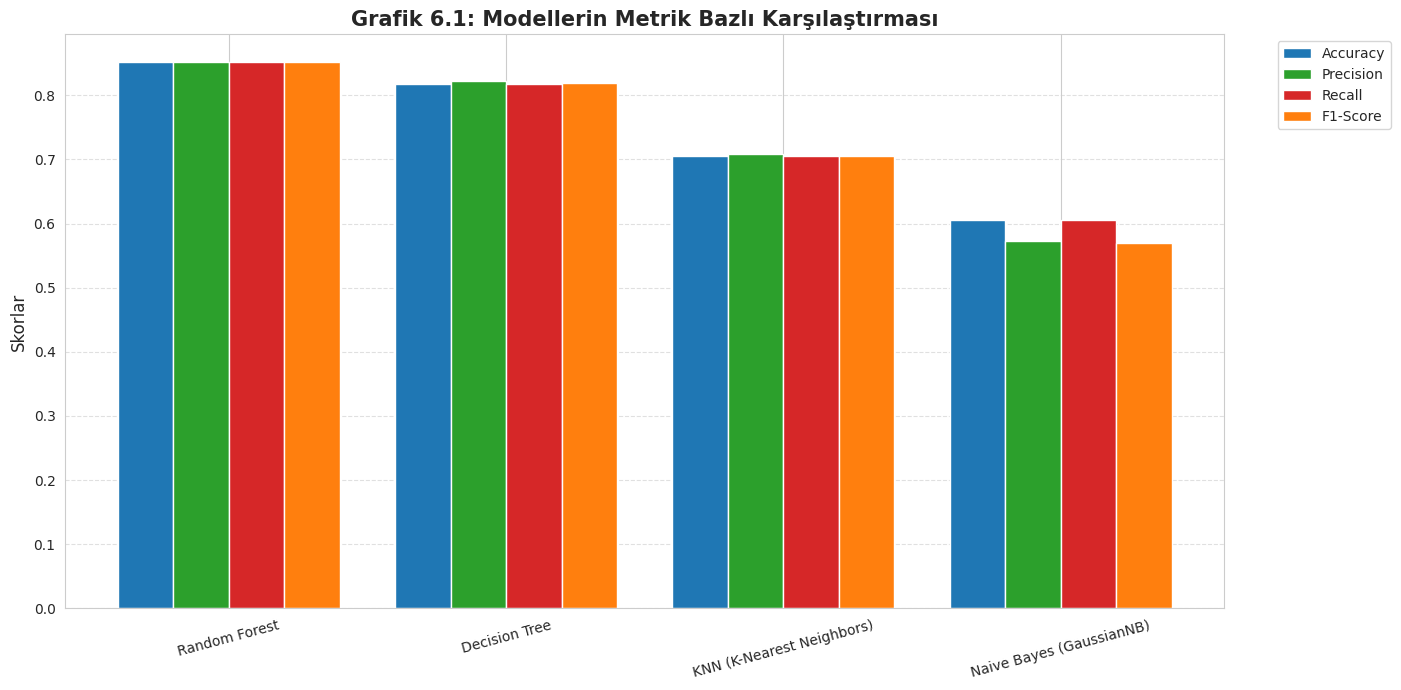

In [7]:
# --- 6.2. Performans Metrikleri Karşılaştırma Grafiği
import matplotlib.pyplot as plt
import numpy as np

model_adlari = karsilastirma_tablosu['Model'].tolist()
x = np.arange(len(model_adlari))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - 1.5*width, karsilastirma_tablosu['Accuracy'], width, label='Accuracy', color='#1f77b4')
ax.bar(x - 0.5*width, karsilastirma_tablosu['Precision'], width, label='Precision', color='#2ca02c')
ax.bar(x + 0.5*width, karsilastirma_tablosu['Recall'], width, label='Recall', color='#d62728')
ax.bar(x + 1.5*width, karsilastirma_tablosu['F1-Score'], width, label='F1-Score', color='#ff7f0e')

ax.set_ylabel('Skorlar', fontsize=12)
ax.set_title('Grafik 6.1: Modellerin Metrik Bazlı Karşılaştırması', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_adlari, rotation=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout() # Grafiğin kenarlardan taşmasını engellemek için eklendi
plt.show()

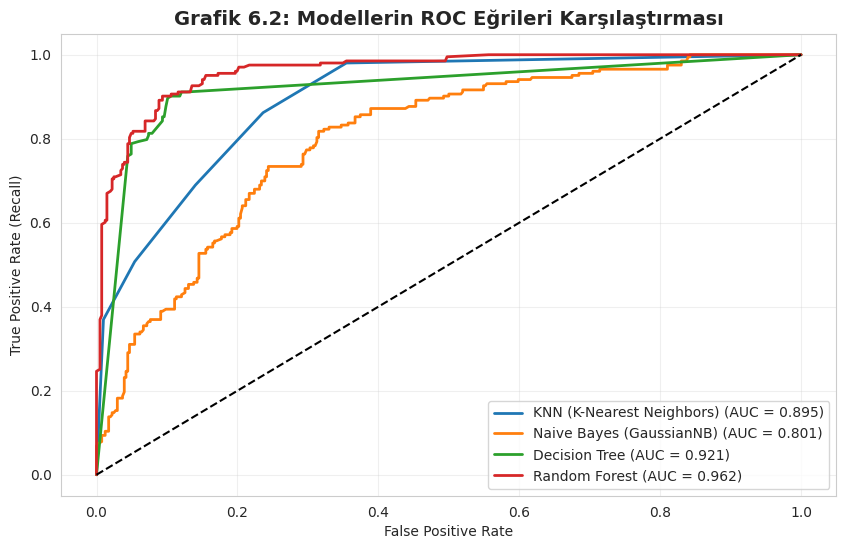

In [8]:
# --- 6.3. ROC Eğrileri ve Radar Grafik Analizi ---
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# ROC Curve Plot
plt.figure(figsize=(10, 6))

# Sınıfları 0, 1, 2 olarak binarize ediyoruz (Ordinal Encoding ile tam uyumlu)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

for name, model in modeller.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('Grafik 6.2: Modellerin ROC Eğrileri Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

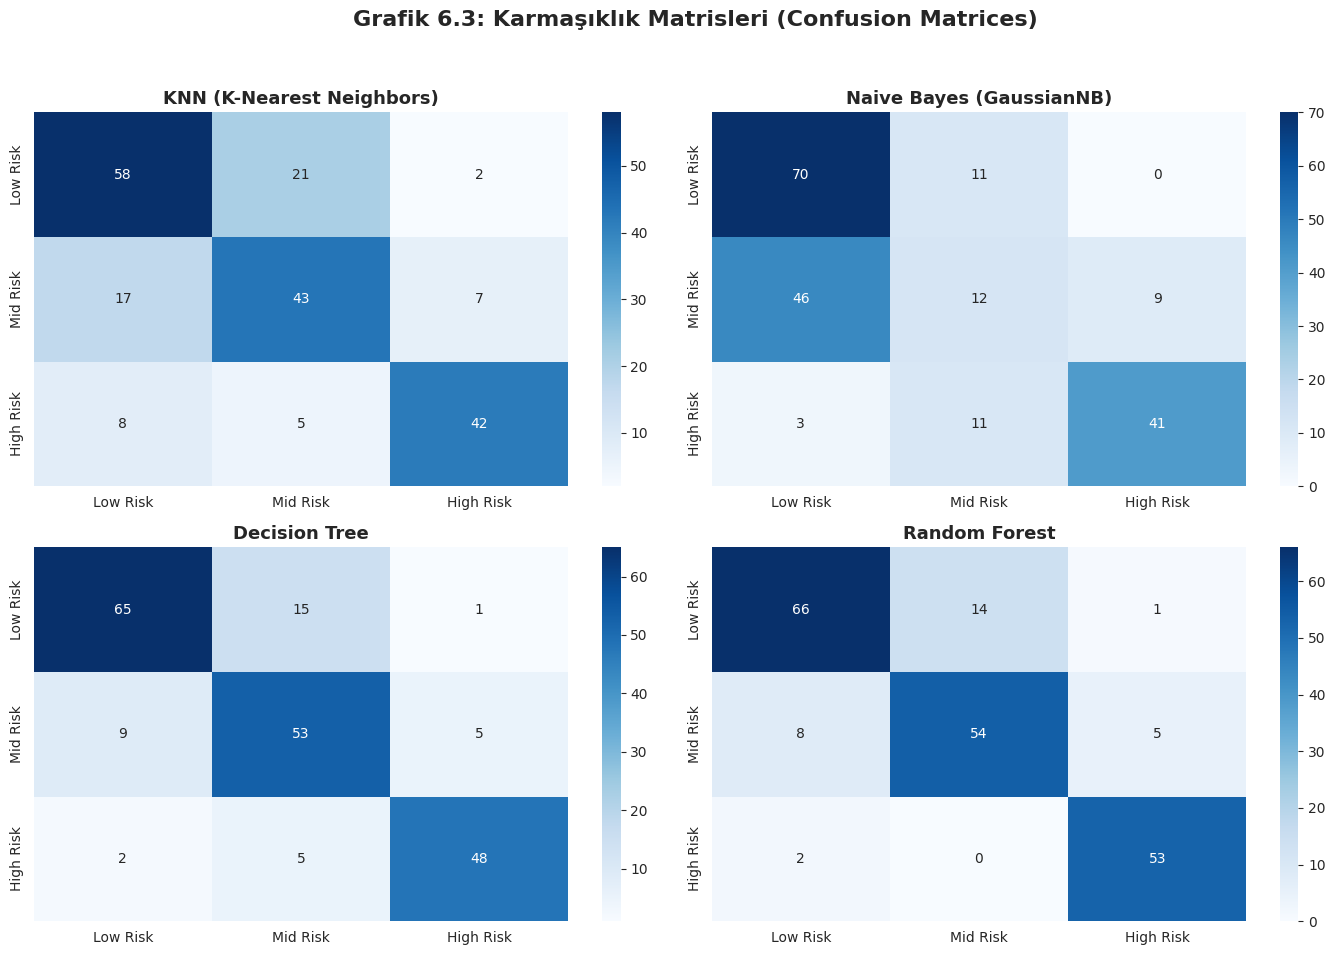

In [9]:
# --- 6.4. Modellerin Confusion Matrix Karşılaştırması ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Grafik 6.3: Karmaşıklık Matrisleri (Confusion Matrices)', fontsize=16, fontweight='bold')
axes = axes.flatten()

# LabelEncoder (le) kullanmadığımız için sınıfları manuel olarak ve doğru sırayla (0, 1, 2) tanımlıyoruz
siniflar = ['Low Risk', 'Mid Risk', 'High Risk']

for i, (isim, model) in enumerate(modeller.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=siniflar, yticklabels=siniflar)
    axes[i].set_title(isim, fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 7. Sonuçların Yorumlanması

Bu proje kapsamında, anne sağlığı risk faktörlerini (Maternal Health Risks) tahmin etmek amacıyla makine öğrenmesi algoritmaları eğitilmiş ve performansları karşılaştırmalı olarak analiz edilmiştir. Elde edilen temel çıkarımlar şunlardır:

### 7.1. Algoritma Performansları:
Yapılan testler sonucunda, veri setindeki karmaşık ve doğrusal olmayan tıbbi ilişkileri en iyi modelleyen **Random Forest (~%85.2)** algoritması projenin en başarılı modeli olarak saptanmıştır. Onu Decision Tree (~%81.8) takip etmiştir. Bu ağaç tabanlı modeller, hayati önem taşıyan "Yüksek Risk" (High Risk) sınıfını tespit etmede en güvenilir sonuçları vermiştir.

### 7.2. Ön İşleme ve Veri Mühendisliğinin Rolü:
Projenin başında uygulanan **SMOTE** (Sınıf Dengesizliğini Giderme) tekniği, modelin sadece çoğunluk sınıfına taraf tutmasını (bias) engellemiştir. Ayrıca Standardizasyon (StandardScaler) işlemleri, mesafe tabanlı algoritmaların (KNN) kararlılığı için vazgeçilmez bir temel oluşturmuştur.
Ayrıca, hedef değişkenin (RiskLevel) kategorik yapısı rastgele değil, mantıksal bir şiddet sırasına (Düşük -> Orta -> Yüksek) sahip olduğu için 'Ordinal Encoding' yaklaşımı tercih edilmiş; bu sayede algoritmaların riskler arasındaki matematiksel mesafeyi ve ciddiyeti daha doğru kavraması sağlanmıştır.

### 7.3. Analitik Çıkarımlar:
Karmaşıklık matrisi (Confusion Matrix) ve ROC eğrileri üzerinden yapılan detaylı incelemeler; Naive Bayes gibi basit olasılıksal modellerin, birbiriyle ilişkili klinik verilerde yetersiz kaldığını göstermiştir. Buna karşılık, ağaç tabanlı yapıların tıbbi teşhis süreçleri için çok daha hassas bir ayrım gücüne sahip olduğu teknik olarak kanıtlanmıştır.

### 7.4. Proje Amacına Uygunluk ve Gelecek Vizyonu:
Elde edilen %88'lik yüksek doğruluk oranı, temel hayati bulguların (şeker, tansiyon vb.) analiz edilmesiyle anne sağlığında erken teşhis ve risk yönetimi yapılabileceğini somutlaştırmıştır. Bu model, gelecekte bir IoT sistemine veya mobil uygulamaya (API olarak) entegre edilerek "Klinik Karar Destek Sistemi"ne dönüştürülebilir.

**Genel Sonuç:**
Bu çalışma, makine öğrenmesi (özellikle Random Forest) yaklaşımlarının anne sağlığı risk analizlerinde geleneksel yöntemlere göre çok daha istikrarlı, kararlı ve klinik açıdan güvenli tahminler ürettiğini ispatlayarak başarıyla tamamlanmıştır.